<a href="https://colab.research.google.com/github/AliRaddman/divar-ml-project/blob/main/notebooks/work/clustering_ali.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<div dir="rtl" align="right">

# مسئله ۱: ساخت سیستم توصیه‌گر با خوشه‌بندی

در این نوت‌بوک، بخش مربوط به علی از مسئله اول یادگیری ماشین انجام می‌شود. هدف این بخش آماده‌سازی داده، انتخاب ویژگی‌های مناسب برای خوشه‌بندی، اجرای الگوریتم KMeans با ۱۰ خوشه، رسم خوشه‌ها و تفسیر آن‌ها برای استفاده در سیستم توصیه‌گر ملک است.

</div>

<div dir="rtl" align="right">

## 1. راه‌اندازی محیط

در این سلول کتابخانه‌های اصلی، مسیر فایل نهایی preprocessing و تنظیمات ثابت پروژه تعریف می‌شوند.  
برای تکرارپذیری نتایج، مقدار ثابت `random_state` برابر با `42` در نظر گرفته می‌شود.

</div>

In [21]:
!pip install -q pyarrow

import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

warnings.filterwarnings("ignore")

# تنظیمات نمایش pandas
pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

# تنظیمات ثابت پروژه
RANDOM_STATE = 42

# مسیر فایل نهایی preprocessing
DATA_PATH = Path("/content/drive/MyDrive/divar_project/cleaned_step3_geo.parquet")

# مسیر پوشه خروجی‌های تیم
PROJECT_OUTPUT_DIR = Path("/content/drive/MyDrive/divar_project")

print("Setup completed.")
print("DATA_PATH:", DATA_PATH)

Setup completed.
DATA_PATH: /content/drive/MyDrive/divar_project/cleaned_step3_geo.parquet


<div dir="rtl" align="right">

## 2. اتصال Google Drive و خواندن داده

داده نهایی مورد استفاده برای بخش یادگیری ماشین، خروجی مرحله سوم preprocessing است:

`cleaned_step3_geo.parquet`

در این سلول ابتدا Google Drive به Colab متصل می‌شود، سپس فایل نهایی خوانده می‌شود.  
در این مرحله هنوز هیچ فیلتری روی داده اعمال نمی‌کنیم.

</div>

In [22]:
from google.colab import drive

# اتصال Google Drive به Colab
drive.mount("/content/drive")

# بررسی وجود فایل ورودی
if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"فایل پیدا نشد. مسیر را بررسی کن:\n{DATA_PATH}"
    )

# خواندن دیتای نهایی preprocessing
df = pd.read_parquet(DATA_PATH)

print("Data loaded successfully.")
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]:,}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Data loaded successfully.
Rows: 999,943
Columns: 85


<div dir="rtl" align="right">

## بررسی ستون‌های موردنیاز برای خوشه‌بندی

در این مرحله بررسی می‌کنیم ستون‌های لازم برای آماده‌سازی داده خوشه‌بندی در دیتاست وجود داشته باشند.

این کار قبل از فیلتر کردن داده انجام می‌شود تا مطمئن شویم فایل نهایی preprocessing همان نسخه مورد انتظار پروژه است.

</div>

In [23]:
# ستون‌های لازم برای ادامه بخش خوشه‌بندی
required_columns = [
    "is_valid_for_price_analysis",
    "is_valid_geo_for_analysis",
    "target_price",
    "target_price_type",
    "target_price_per_m2",
    "utm_easting",
    "utm_northing",
    "utm_zone_number",
    "utm_zone_letter",
    "building_size_pos",
    "rooms_count",
]

# بررسی ستون‌های گم‌شده
missing_columns = [col for col in required_columns if col not in df.columns]

if missing_columns:
    print("Missing columns:")
    for col in missing_columns:
        print("-", col)
    raise ValueError("بعضی از ستون‌های لازم در دیتاست وجود ندارند.")
else:
    print("All required columns are available.")

print("\nDataset shape:")
print(df.shape)

print("\nPreview of required columns:")
display(df[required_columns].head())

All required columns are available.

Dataset shape:
(999943, 85)

Preview of required columns:


,is_valid_for_price_analysis,is_valid_geo_for_analysis,target_price,target_price_type,target_price_per_m2,utm_easting,utm_northing,utm_zone_number,utm_zone_letter,building_size_pos,rooms_count
0,False,True,NaN,not_defined,NaN,"494,272.33","3,963,063.60",39,S,500.00,3.00
1,True,False,"8,500,000,000.00",sale_total_price,"141,666,666.67",NaN,NaN,<NA>,<NA>,60.00,1.00
2,True,True,"48,500,000.00",monthly_rent_equivalent,"367,424.24","533,784.42","3,951,167.83",39,S,132.00,3.00
3,True,False,"123,500,000.00",monthly_rent_equivalent,"1,372,222.22",NaN,NaN,<NA>,<NA>,90.00,1.00
4,True,False,"5,750,000,000.00",sale_total_price,"50,000,000.00",NaN,NaN,<NA>,<NA>,115.00,2.00


<div dir="rtl" align="right">

## بررسی اولیه داده برای شروع خوشه‌بندی

در این مرحله تعداد ردیف‌های معتبر از نظر قیمت، جغرافیا و مختصات UTM بررسی می‌شود.

هدف این سلول این است که قبل از ساخت داده نهایی خوشه‌بندی، مطمئن شویم بیشترین حجم داده واقعاً مربوط به zone موردنظر پروژه است.

</div>

In [24]:
print("Initial clustering data checks")
print("-" * 50)

total_rows = len(df)

valid_price_rows = df["is_valid_for_price_analysis"].sum()
valid_geo_rows = df["is_valid_geo_for_analysis"].sum()
positive_target_rows = (df["target_price"] > 0).sum()

print(f"Total rows: {total_rows:,}")
print(f"Valid for price analysis: {valid_price_rows:,}")
print(f"Valid geo for analysis: {valid_geo_rows:,}")
print(f"Positive target_price: {positive_target_rows:,}")

print("\nTop UTM zones among valid geo rows:")

utm_zone_summary = (
    df.loc[df["is_valid_geo_for_analysis"] == True]
      .groupby(["utm_zone_number", "utm_zone_letter"], dropna=False)
      .size()
      .reset_index(name="count")
      .sort_values("count", ascending=False)
)

utm_zone_summary["share_percent"] = (
    utm_zone_summary["count"] / utm_zone_summary["count"].sum() * 100
).round(2)

display(utm_zone_summary.head(10))

Initial clustering data checks
--------------------------------------------------
Total rows: 999,943
Valid for price analysis: 877,587
Valid geo for analysis: 655,576
Positive target_price: 917,334

Top UTM zones among valid geo rows:


,utm_zone_number,utm_zone_letter,count,share_percent
3,39,S,452153,68.97
5,40,S,64641,9.86
1,38,S,54417,8.30
2,39,R,52891,8.07
4,40,R,25027,3.82
6,41,R,5951,0.91
7,41,S,460,0.07
0,38,R,36,0.01


<div dir="rtl" align="right">

## ساخت داده پایه مشترک برای خوشه‌بندی

در این مرحله داده‌ای ساخته می‌شود که مبنای مشترک بخش علی و بنیامین در مسئله ۱ است.

فیلترهای این مرحله شامل اعتبار قیمت، اعتبار جغرافیا، مثبت بودن قیمت هدف و محدود شدن به UTM zone اصلی داده است.

در این سلول فقط داده پایه ساخته می‌شود و هنوز sample، scale یا مدل خوشه‌بندی اجرا نمی‌شود.

</div>

In [25]:
# فیلتر پایه مشترک برای مسئله ۱
base_filter = (
    (df["is_valid_for_price_analysis"] == True) &
    (df["is_valid_geo_for_analysis"] == True) &
    (df["target_price"] > 0) &
    (df["utm_zone_number"] == 39) &
    (df["utm_zone_letter"] == "S")
)

# ستون‌هایی که در ادامه برای تحلیل خوشه‌بندی لازم داریم
base_columns = [
    "cat2_slug",
    "cat3_slug",
    "city_slug",
    "neighborhood_slug",
    "target_price",
    "target_price_type",
    "target_price_per_m2",
    "utm_easting",
    "utm_northing",
    "utm_zone_number",
    "utm_zone_letter",
    "building_size_pos",
    "rooms_count",
]

# ساخت دیتای پایه خوشه‌بندی
cluster_df_base = df.loc[base_filter, base_columns].copy()

# ساخت نسخه لگاریتمی قیمت هدف برای کاهش اثر مقادیر بسیار بزرگ
cluster_df_base["log_target_price"] = np.log1p(cluster_df_base["target_price"])

print("Base clustering data created.")
print(f"Rows: {cluster_df_base.shape[0]:,}")
print(f"Columns: {cluster_df_base.shape[1]:,}")

print("\nMissing values in key clustering columns:")
display(
    cluster_df_base[
        [
            "utm_easting",
            "utm_northing",
            "target_price",
            "log_target_price",
            "building_size_pos",
            "rooms_count",
        ]
    ].isna().sum().to_frame("missing_count")
)

print("\nPreview:")
display(cluster_df_base.head())

Base clustering data created.
Rows: 404,253
Columns: 14

Missing values in key clustering columns:


,missing_count
utm_easting,0
utm_northing,0
target_price,0
log_target_price,0
building_size_pos,0
rooms_count,0



Preview:


,cat2_slug,cat3_slug,city_slug,neighborhood_slug,target_price,target_price_type,target_price_per_m2,utm_easting,utm_northing,utm_zone_number,utm_zone_letter,building_size_pos,rooms_count,log_target_price
2,residential-rent,apartment-rent,tehran,tohid,"48,500,000.00",monthly_rent_equivalent,"367,424.24","533,784.42","3,951,167.83",39,S,132.00,3.00,17.70
7,residential-sell,apartment-sell,tehran,dardasht,"8,700,000,000.00",sale_total_price,"87,000,000.00","545,711.56","3,954,101.26",39,S,100.00,2.00,22.89
8,residential-sell,apartment-sell,mahdasht-city,NaN,"650,000,000.00",sale_total_price,"8,333,333.33","481,437.13","3,952,065.61",39,S,78.00,2.00,20.29
10,residential-sell,apartment-sell,pardis-city,NaN,"2,600,000,000.00",sale_total_price,"29,885,057.47","568,467.03","3,959,664.11",39,S,87.00,2.00,21.68
11,residential-rent,apartment-rent,tehran,gisha,"36,000,000.00",monthly_rent_equivalent,"395,604.40","534,418.19","3,954,507.21",39,S,91.00,2.00,17.40


<div dir="rtl" align="right">

## استفاده از کل داده معتبر برای بخش KMeans

در این بخش برای اجرای KMeans با ۱۰ خوشه از کل داده معتبر فیلترشده استفاده می‌کنیم.

چون داده پایه پس از فیلترهای قیمت، جغرافیا و UTM zone 39S حدود چهارصد هزار ردیف دارد، اجرای KMeans روی کل داده در Colab قابل قبول است.

در مراحل بعدی، اگر scatter plot بیش از حد شلوغ شود، فقط برای نمایش نمودار از نمونه‌گیری جداگانه استفاده می‌کنیم؛ اما مدل اصلی روی کل داده اجرا می‌شود.

</div>

In [26]:
# استفاده از کل داده پایه برای اجرای KMeans
cluster_df = cluster_df_base.copy()

print("Full clustering data selected.")
print(f"Rows used for clustering: {len(cluster_df):,}")
print(f"Columns: {cluster_df.shape[1]:,}")

print("\nTarget price type distribution:")
display(
    cluster_df["target_price_type"]
    .value_counts(dropna=False)
    .reset_index(name="count")
    .rename(columns={"index": "target_price_type"})
)

Full clustering data selected.
Rows used for clustering: 404,253
Columns: 14

Target price type distribution:


,target_price_type,count
0,sale_total_price,248870
1,monthly_rent_equivalent,155383


<div dir="rtl" align="right">

## انتخاب ویژگی‌های نهایی برای خوشه‌بندی

در این بخش پنج ویژگی برای اجرای خوشه‌بندی انتخاب می‌شوند:

`utm_easting`

`utm_northing`

`log_target_price`

`building_size_pos`

`rooms_count`

دو ویژگی اول موقعیت مکانی ملک را نشان می‌دهند.  
ویژگی سوم سطح قیمت را با اثر کمترِ مقادیر بسیار بزرگ وارد مدل می‌کند.  
دو ویژگی آخر مشخصات پایه ملک را نشان می‌دهند.

تعداد ویژگی‌ها عمداً محدود نگه داشته شده است تا خوشه‌بندی بیش از حد پیچیده نشود و دچار نفرین ابعاد نشویم.

</div>

In [27]:
# ویژگی‌های نهایی برای بخش KMeans علی
kmeans_features = [
    "utm_easting",
    "utm_northing",
    "log_target_price",
    "building_size_pos",
    "rooms_count",
]

# ساخت ماتریس ویژگی‌ها
X = cluster_df[kmeans_features].copy()

# بررسی مقدارهای گم‌شده
missing_in_features = X.isna().sum()

if missing_in_features.sum() > 0:
    print("Missing values found:")
    display(missing_in_features.to_frame("missing_count"))
    raise ValueError("در ویژگی‌های انتخاب‌شده مقدار گم‌شده وجود دارد.")
else:
    print("No missing values in selected features.")

# مقیاس‌بندی ویژگی‌ها
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# تبدیل خروجی scale شده به DataFrame برای بررسی بهتر
X_scaled_df = pd.DataFrame(
    X_scaled,
    columns=kmeans_features,
    index=cluster_df.index
)

print("\nFeature matrix created and scaled.")
print(f"X shape: {X.shape}")
print(f"X_scaled shape: {X_scaled.shape}")

print("\nScaled features summary:")
display(X_scaled_df.describe().T)

No missing values in selected features.

Feature matrix created and scaled.
X shape: (404253, 5)
X_scaled shape: (404253, 5)

Scaled features summary:


,count,mean,std,min,25%,50%,75%,max
utm_easting,"404,253.00",-0.00,1.00,-3.23,-0.11,0.32,0.50,3.27
utm_northing,"404,253.00",0.00,1.00,-3.06,0.01,0.14,0.23,3.58
log_target_price,"404,253.00",0.00,1.00,-3.50,-1.07,0.41,0.80,2.56
building_size_pos,"404,253.00",0.00,1.00,-0.26,-0.18,-0.14,-0.08,28.06
rooms_count,"404,253.00",0.00,1.00,-2.15,-0.99,0.16,0.16,3.62


<div dir="rtl" align="right">

## اجرای KMeans با ۱۰ خوشه

در این مرحله الگوریتم KMeans با ۱۰ خوشه روی ویژگی‌های مقیاس‌بندی‌شده اجرا می‌شود.

تعداد خوشه‌ها طبق صورت مسئله برابر با ۱۰ در نظر گرفته شده است.

پس از اجرای مدل، برچسب خوشه هر آگهی به داده اضافه می‌شود تا در مراحل بعد بتوانیم خوشه‌ها را رسم و تفسیر کنیم.

</div>

In [28]:
# اجرای KMeans با ۱۰ خوشه طبق صورت مسئله
kmeans_10 = KMeans(
    n_clusters=10,
    random_state=RANDOM_STATE,
    n_init=10
)

cluster_labels = kmeans_10.fit_predict(X_scaled)

# اضافه کردن label خوشه به داده اصلی clustering
cluster_df["kmeans_cluster_10"] = cluster_labels

print("KMeans with 10 clusters completed.")
print(f"Inertia / WCSS: {kmeans_10.inertia_:,.2f}")

print("\nCluster counts:")
cluster_counts = (
    cluster_df["kmeans_cluster_10"]
    .value_counts()
    .sort_index()
    .reset_index()
)

cluster_counts.columns = ["cluster", "count"]
cluster_counts["share_percent"] = (
    cluster_counts["count"] / len(cluster_df) * 100
).round(2)

display(cluster_counts)

# مرکز خوشه‌ها در فضای scale شده
centers_scaled = pd.DataFrame(
    kmeans_10.cluster_centers_,
    columns=kmeans_features
)

# مرکز خوشه‌ها در مقیاس اصلی ویژگی‌ها
centers_original = pd.DataFrame(
    scaler.inverse_transform(kmeans_10.cluster_centers_),
    columns=kmeans_features
)

centers_original.insert(0, "cluster", range(10))

print("\nCluster centers in original feature scale:")
display(centers_original)

KMeans with 10 clusters completed.
Inertia / WCSS: 525,870.04

Cluster counts:


,cluster,count,share_percent
0,0,44689,11.05
1,1,34859,8.62
2,2,38177,9.44
3,3,30965,7.66
4,4,105825,26.18
5,5,437,0.11
6,6,2133,0.53
7,7,47936,11.86
8,8,24155,5.98
9,9,75077,18.57



Cluster centers in original feature scale:


,cluster,utm_easting,utm_northing,log_target_price,building_size_pos,rooms_count
0,0,"521,629.94","3,948,057.86",21.63,85.93,0.87
1,1,"539,397.25","3,971,874.01",22.49,226.61,3.36
2,2,"353,221.46","4,127,935.44",20.28,216.53,1.92
3,3,"554,360.52","3,617,949.73",19.92,176.26,1.93
4,4,"534,435.75","3,964,004.63",21.97,160.99,2.00
5,5,"435,955.70","3,959,843.90",22.35,"14,913.97",1.74
6,6,"445,602.66","3,951,132.85",22.04,"5,894.88",1.88
7,7,"518,365.62","3,946,386.54",16.35,76.47,0.72
8,8,"298,299.87","3,748,495.11",19.29,181.74,1.78
9,9,"526,123.60","3,955,723.74",17.06,121.75,2.25


<div dir="rtl" align="right">

## ساخت جدول خلاصه خوشه‌ها

در این مرحله برای هر خوشه، تعداد آگهی‌ها، سهم از کل داده، میانه و میانگین قیمت، میانه و میانگین متراژ، تعداد اتاق و مختصات مکانی محاسبه می‌شود.

این جدول کمک می‌کند خوشه‌ها از نظر قیمت، موقعیت و مشخصات ملک قابل تفسیر شوند.

</div>

In [29]:
# ساخت جدول خلاصه برای خوشه‌های KMeans
cluster_summary = (
    cluster_df
    .groupby("kmeans_cluster_10")
    .agg(
        count=("kmeans_cluster_10", "size"),
        target_price_median=("target_price", "median"),
        target_price_mean=("target_price", "mean"),
        log_target_price_median=("log_target_price", "median"),
        building_size_median=("building_size_pos", "median"),
        building_size_mean=("building_size_pos", "mean"),
        rooms_median=("rooms_count", "median"),
        rooms_mean=("rooms_count", "mean"),
        utm_easting_median=("utm_easting", "median"),
        utm_northing_median=("utm_northing", "median"),
    )
    .reset_index()
    .rename(columns={"kmeans_cluster_10": "cluster"})
)

# سهم هر خوشه از کل داده
cluster_summary["share_percent"] = (
    cluster_summary["count"] / len(cluster_df) * 100
).round(2)

# مرتب‌سازی ستون‌ها
cluster_summary = cluster_summary[
    [
        "cluster",
        "count",
        "share_percent",
        "target_price_median",
        "target_price_mean",
        "log_target_price_median",
        "building_size_median",
        "building_size_mean",
        "rooms_median",
        "rooms_mean",
        "utm_easting_median",
        "utm_northing_median",
    ]
]

# نمایش خواناتر جدول
display(cluster_summary.sort_values("cluster"))

,cluster,count,share_percent,target_price_median,target_price_mean,log_target_price_median,building_size_median,building_size_mean,rooms_median,rooms_mean,utm_easting_median,utm_northing_median
0,0,44689,11.05,"2,395,000,000.00","3,959,636,204.04",21.60,56.00,85.93,1.00,0.87,"527,800.31","3,949,303.35"
1,1,34859,8.62,"7,500,000,000.00","13,558,853,006.47",22.74,164.00,226.36,3.00,3.36,"537,320.70","3,959,072.54"
2,2,38177,9.44,"1,750,000,000.00","2,745,773,007.15",21.28,105.00,216.53,2.00,1.92,"373,176.51","4,126,474.23"
3,3,30965,7.66,"1,600,000,000.00","3,385,387,816.18",21.19,115.00,176.49,2.00,1.93,"561,079.26","3,613,881.91"
4,4,105825,26.18,"3,290,000,000.00","5,835,564,878.84",21.91,95.00,160.99,2.00,2.00,"529,781.46","3,954,996.31"
5,5,437,0.11,"7,000,000,000.00","34,748,459,204.31",22.67,"14,000.00","14,913.97",2.00,1.74,"426,678.83","3,966,862.38"
6,6,2133,0.53,"4,000,000,000.00","22,382,868,876.62",22.11,"5,000.00","5,894.88",2.00,1.88,"446,804.65","3,959,330.19"
7,7,47936,11.86,"12,000,000.00","19,478,966.43",16.30,60.00,76.43,1.00,0.72,"530,141.46","3,950,572.64"
8,8,24155,5.98,"830,000,000.00","2,167,221,035.36",20.54,105.00,181.74,2.00,1.78,"273,958.37","3,770,023.79"
9,9,75077,18.57,"25,000,000.00","37,739,024.03",17.03,100.00,121.83,2.00,2.25,"530,682.02","3,955,276.42"


<div dir="rtl" align="right">

## بررسی اثر متراژهای بسیار بزرگ روی خوشه‌بندی

در خروجی اولیه KMeans، دو خوشه کوچک با میانگین متراژ بسیار بالا دیده شد.

در این مرحله بررسی می‌کنیم این خوشه‌ها از چه نوع آگهی‌هایی تشکیل شده‌اند و آیا جدا شدن آن‌ها از نظر کاربرد سیستم توصیه‌گر قابل دفاع است یا نه.

در این سلول مدل تغییر نمی‌کند؛ فقط خروجی KMeans از نظر ترکیب دسته‌بندی‌ها و نوع قیمت تحلیل می‌شود.

</div>

In [30]:
print("Building size distribution")
print("-" * 50)

# بررسی صدک‌های متراژ
quantile_values = [0.50, 0.75, 0.90, 0.95, 0.99, 0.995, 0.999, 1.00]
building_size_quantiles = cluster_df["building_size_pos"].quantile(quantile_values)

building_size_quantiles_df = pd.DataFrame({
    "quantile": [f"{q:.3f}" for q in quantile_values],
    "building_size_pos": building_size_quantiles.values
})

display(building_size_quantiles_df)

print("\nCluster 5 and 6 category composition:")
for cluster_id in [5, 6]:
    print(f"\nCluster {cluster_id}")
    print("-" * 30)

    temp = cluster_df.loc[cluster_df["kmeans_cluster_10"] == cluster_id]

    print(f"Rows: {len(temp):,}")
    print(f"Median building_size_pos: {temp['building_size_pos'].median():,.2f}")
    print(f"Mean building_size_pos: {temp['building_size_pos'].mean():,.2f}")

    print("\ncat3_slug distribution:")
    display(
        temp["cat3_slug"]
        .astype("object")
        .value_counts(dropna=False)
        .head(10)
        .rename_axis("cat3_slug")
        .reset_index(name="count")
    )

    print("\ntarget_price_type distribution:")
    display(
        temp["target_price_type"]
        .astype("object")
        .value_counts(dropna=False)
        .rename_axis("target_price_type")
        .reset_index(name="count")
    )

Building size distribution
--------------------------------------------------


,quantile,building_size_pos
0,0.500,95.00
1,0.750,140.00
2,0.900,250.00
3,0.950,450.00
4,0.990,"2,000.00"
5,0.995,"4,000.00"
6,0.999,"11,000.00"
7,1.000,"20,000.00"



Cluster 5 and 6 category composition:

Cluster 5
------------------------------
Rows: 437
Median building_size_pos: 14,000.00
Mean building_size_pos: 14,913.97

cat3_slug distribution:


,cat3_slug,count
0,plot-old,252
1,industry-agriculture-business-sell,135
2,industry-agriculture-business-rent,50



target_price_type distribution:


,target_price_type,count
0,sale_total_price,387
1,monthly_rent_equivalent,50



Cluster 6
------------------------------
Rows: 2,133
Median building_size_pos: 5,000.00
Mean building_size_pos: 5,894.88

cat3_slug distribution:


,cat3_slug,count
0,plot-old,1377
1,industry-agriculture-business-sell,545
2,industry-agriculture-business-rent,207
3,house-villa-rent,4



target_price_type distribution:


,target_price_type,count
0,sale_total_price,1922
1,monthly_rent_equivalent,211


<div dir="rtl" align="right">

## تصمیم تحلیلی درباره متراژهای بسیار بزرگ

در اجرای اولیه

`KMeans`

دو خوشه کوچک با متراژ بسیار بالا شکل گرفتند. بررسی ترکیب این خوشه‌ها نشان داد که این بخش‌ها عمدتاً شامل زمین‌های قدیمی، املاک صنعتی، کشاورزی و تجاری هستند.

بنابراین این خوشه‌ها الزاماً خطای مدل یا نویز نیستند؛ بلکه می‌توانند یک سگمنت واقعی و متمایز از بازار املاک را نشان دهند. از دید سیستم توصیه‌گر، جدا شدن این آگهی‌ها منطقی است، چون کاربری که به‌دنبال زمین یا ملک صنعتی بزرگ است، نیاز متفاوتی نسبت به کاربر متقاضی آپارتمان یا ملک معمولی‌تر دارد.

در نتیجه، در نسخه فعلی بخش علی، متغیر

`building_size_pos`

به‌صورت مستقیم در مدل حفظ می‌شود و خوشه‌های کوچک مربوط به متراژهای بسیار بزرگ به‌عنوان یک بخش خاص از بازار تفسیر می‌شوند.

البته اگر در نسخه‌های بعدی هدف تحلیل به یک نوع خاص از ملک محدود شود، می‌توان داده را بر اساس نوع آگهی جدا کرد یا برای کاهش اثر مقدارهای بسیار بزرگ، نسخه لگاریتمی متراژ را نیز بررسی کرد.

</div>

<div dir="rtl" align="right">

## رسم خوشه‌ها و مراکز خوشه‌ها

در این مرحله خروجی KMeans روی مختصات UTM رسم می‌شود.

هر نقطه نشان‌دهنده یک آگهی است و رنگ آن خوشه مربوط به آن آگهی را نشان می‌دهد.  
مراکز خوشه‌ها نیز با علامت جداگانه روی نمودار مشخص می‌شوند.

برای خواناتر شدن نمودار، مدل همچنان روی کل داده اجرا شده است، اما در صورت زیاد بودن تعداد نقاط، فقط برای نمایش از نمونه‌ای از داده استفاده می‌شود.

</div>

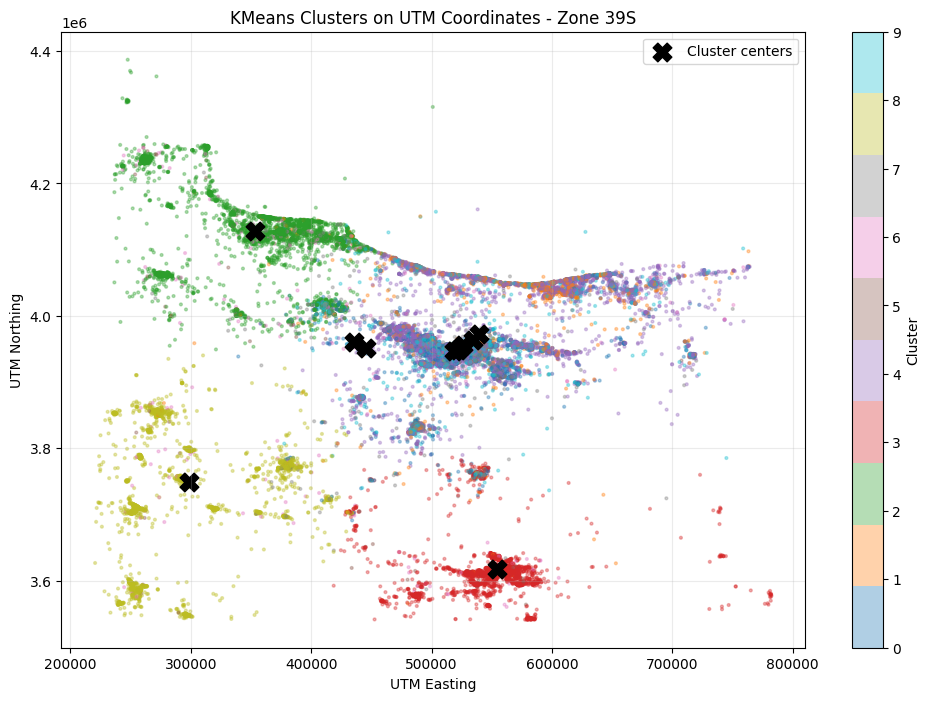

Rows used for model: 404,253
Rows used for plot: 80,000


In [31]:
# نمونه‌گیری فقط برای رسم نمودار، نه برای آموزش مدل
PLOT_SAMPLE_SIZE = 80_000

if len(cluster_df) > PLOT_SAMPLE_SIZE:
    plot_df = cluster_df.sample(
        n=PLOT_SAMPLE_SIZE,
        random_state=RANDOM_STATE
    ).copy()
else:
    plot_df = cluster_df.copy()

plt.figure(figsize=(12, 8))

scatter = plt.scatter(
    plot_df["utm_easting"],
    plot_df["utm_northing"],
    c=plot_df["kmeans_cluster_10"],
    s=4,
    alpha=0.35,
    cmap="tab10"
)

# رسم مراکز خوشه‌ها در مقیاس اصلی مختصات UTM
plt.scatter(
    centers_original["utm_easting"],
    centers_original["utm_northing"],
    c="black",
    s=180,
    marker="X",
    label="Cluster centers"
)

plt.xlabel("UTM Easting")
plt.ylabel("UTM Northing")
plt.title("KMeans Clusters on UTM Coordinates - Zone 39S")
plt.colorbar(scatter, label="Cluster")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

print(f"Rows used for model: {len(cluster_df):,}")
print(f"Rows used for plot: {len(plot_df):,}")

<div dir="rtl" align="right">

### توضیح درباره نزدیک بودن بعضی مراکز خوشه‌ها

در نمودار بالا، بعضی از مراکز خوشه‌ها از نظر مکانی به هم نزدیک دیده می‌شوند. دلیل این موضوع این است که نمودار فقط دو بعد مکانی را نمایش می‌دهد:

`utm_easting`

`utm_northing`

اما الگوریتم

`KMeans`

فقط بر اساس موقعیت مکانی خوشه‌بندی نکرده است. مدل با ترکیبی از پنج ویژگی آموزش داده شده است:

`utm_easting`

`utm_northing`

`log_target_price`

`building_size_pos`

`rooms_count`

بنابراین ممکن است دو خوشه روی نقشه در یک محدوده جغرافیایی نزدیک باشند، اما از نظر سطح قیمت، متراژ یا تعداد اتاق‌ها تفاوت داشته باشند. در چنین حالتی، مرکزهای مکانی آن‌ها نزدیک دیده می‌شود، ولی در فضای کامل ویژگی‌ها دو خوشه جدا محسوب می‌شوند.

این موضوع برای سیستم توصیه‌گر منطقی است؛ چون دو ملک می‌توانند در یک محدوده شهری قرار داشته باشند، اما برای دو نیاز متفاوت کاربر مناسب باشند. برای مثال، یک آگهی کوچک‌تر و ارزان‌تر با یک آگهی بزرگ‌تر و گران‌تر ممکن است از نظر مکانی نزدیک باشند، اما نباید الزاماً در یک گروه پیشنهادی قرار بگیرند.

</div>

<div dir="rtl" align="right">

## تفسیر نهایی خوشه‌ها برای سیستم توصیه‌گر

خوشه‌بندی انجام‌شده نشان می‌دهد که آگهی‌های املاک را می‌توان بر اساس ترکیبی از موقعیت مکانی، سطح قیمت، متراژ و تعداد اتاق‌ها به چند گروه متمایز تقسیم کرد.

در این تحلیل، ویژگی‌های زیر برای خوشه‌بندی استفاده شدند:

`utm_easting`

`utm_northing`

`log_target_price`

`building_size_pos`

`rooms_count`

استفاده از مختصات

`UTM`

باعث شد فاصله مکانی بین آگهی‌ها در یک zone مشخص قابل مقایسه باشد. به همین دلیل، تحلیل فقط روی

`UTM zone 39S`

انجام شد؛ چون بیشترین حجم داده معتبر در این zone قرار داشت و مقایسه مستقیم مختصات بین zoneهای مختلف معتبر نیست.

ویژگی

`log_target_price`

برای وارد کردن سطح قیمت به مدل استفاده شد تا تفاوت بین آگهی‌های ارزان، متوسط و گران در خوشه‌بندی اثرگذار باشد. استفاده از لگاریتم قیمت باعث می‌شود قیمت‌های بسیار بزرگ کل ساختار خوشه‌بندی را بیش از حد تحت تأثیر قرار ندهند.

ویژگی‌های

`building_size_pos`

و

`rooms_count`

نیز برای وارد کردن مشخصات پایه ملک استفاده شدند. این دو ویژگی کمک می‌کنند آگهی‌هایی که از نظر متراژ و تعداد اتاق مشابه هستند، در کنار آگهی‌های نزدیک از نظر مکانی و قیمتی قرار بگیرند.

در خروجی

`KMeans`

با

`10`

خوشه، بعضی خوشه‌ها سهم بزرگی از داده را تشکیل می‌دهند و بیشتر نماینده آگهی‌های رایج بازار هستند. در مقابل، خوشه‌های کوچک‌تر، مخصوصاً خوشه‌های مربوط به متراژهای بسیار بزرگ، بیشتر شامل زمین، املاک صنعتی، کشاورزی یا تجاری هستند. این موضوع الزاماً خطای مدل نیست؛ بلکه می‌تواند یک بخش خاص و واقعی از بازار املاک را نشان دهد.

از دید سیستم توصیه‌گر، این خوشه‌ها می‌توانند برای پیشنهاد آگهی‌های مشابه استفاده شوند. برای مثال، وقتی کاربر یک آگهی را مشاهده می‌کند، سیستم می‌تواند ابتدا خوشه همان آگهی را پیدا کند و سپس آگهی‌هایی را پیشنهاد دهد که در همان خوشه قرار دارند. این روش باعث می‌شود پیشنهادها از نظر موقعیت، قیمت، متراژ و نوع کلی نیاز کاربر به هم نزدیک‌تر باشند.

محدود نگه داشتن تعداد ویژگی‌ها نیز برای جلوگیری از پیچیده شدن بیش از حد مدل و کاهش خطر نفرین ابعاد انجام شد. در نتیجه، خوشه‌ها ساده‌تر، قابل تفسیرتر و برای ارائه در سیستم توصیه‌گر قابل دفاع‌تر هستند.

</div>